### CS/ECE/ISyE 524 &mdash; Introduction to Optimization &mdash; Spring 2026 ###

# Project title goes here #

#### Ian Guo (yguo388@wisc.edu), Muxin Li (mli936@wis.edu), Leopold Dong (ldong63@wisc.edu)

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Implementation and Solution](#3.-Implementation)
1. [Discussion of Results](#4.-Results-discussion)
1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

What does it cost, in dollars and in carbon, to eat well? This project uses multi-objective linear programming to design optimal daily diets that simultaneously minimize financial cost and greenhouse gas (GHG) emissions. By applying the epsilon-constraint method, we construct a Pareto frontier that makes the precise trade-off between eating economically and eating sustainably visible and quantifiable. We further examine how medically motivated dietary restrictions, specifically for diabetes and hypertension, shift this frontier and change the marginal cost of reducing carbon emissions.

The idea of optimizing a diet mathematically is not new. In 1939, economist George Stigler posed what became a landmark problem in operations research: what is the cheapest possible diet that still meets a person's basic nutritional needs? His answer, a monotonous regimen of wheat flour, cabbage, and pork liver, was solved by hand and later became one of the first problems solved by the simplex method when it was introduced by George Dantzig in 1947 (Dantzig, 1990). The "Stigler Diet" demonstrated that linear programming could find globally optimal solutions to real-world resource allocation problems, and diet optimization has served as a teaching example in optimization ever since.

Today, the challenge is considerably richer. The global food system accounts for roughly 26% of all greenhouse gas emissions worldwide (Poore & Nemecek, 2018), and the carbon footprint of what we eat varies enormously by food type. Beef, for instance, produces more than 60 kg of CO₂ equivalent per kilogram of food, while legumes produce less than 1 kg. As climate concerns grow alongside rising food costs, the ability to quantify and navigate the tension between affordability and sustainability has become a genuinely practical policy question, not just an academic exercise.

**Data Collection.** This project integrates two publicly available, real-world datasets. Nutritional information comes from the CORGIS Food dataset, which provides macronutrient profiles, calories, protein, fat, carbohydrates, fiber, sodium, and saturated fat, for approximately 300 food items. Emissions data comes from Our World in Data, drawing on Poore & Nemecek's (2018) global meta-analysis of food lifecycle assessments, and provides kilograms of CO₂ equivalent per kilogram of food across roughly 40 broad food categories. The two datasets are merged by mapping each food item's category label (e.g., "Beef," "Poultry," "Milk") to its corresponding emissions entry.

**Key Simplifying Assumptions.** Because the two datasets do not share a common price column, food prices are synthetically generated using a repeating pattern of representative costs based on typical grocery store values. Emissions are assigned at the category level rather than the individual food item level, meaning all beef products share the same GHG intensity regardless of cut or preparation. Each food item is treated as a continuous decision variable representing daily servings, bounded between 0 and 5. Nutritional constraints are modeled as daily minimum (or maximum) thresholds based on standard dietary reference values, without accounting for meal structure, palatability, or variety.

**Outline.** The remainder of this report is organized as follows. Section 2 presents the mathematical model, defining the decision variables, objective function, constraints, and the epsilon-constraint approach used to trace the Pareto frontier. Section 3 describes the implementation in Julia using the JuMP package and the HiGHS solver, with separate model variants for three dietary scenarios: a general healthy diet, a diabetic-friendly diet, and a hypertension-friendly diet. Section 4 presents and interprets the results, including the Pareto frontier curves and shadow price analysis for each scenario. Section 5 concludes with a summary of findings and directions for future work.

**References:**

Dantzig, George B. "The diet problem." Interfaces 20, no. 4 (1990): 43-47.

Poore, Joseph, and Thomas Nemecek. "Reducing food's environmental impacts through producers and consumers." Science 360, no. 6392 (2018): 987-992.


## 2. Mathematical model ##

A discussion of the modeling assumptions made in the problem (e.g. is it from physics? economics? something else?). Explain the decision variables, the constraints, and the objective function. Finally, show the optimization problem written in standard form. If converting the problem to standard form would create a difficult-to-read model, it is okay to leave it in its simplest original form. Equations should be formatted in $\\LaTeX$ within the IJulia notebook. For this section you may **assume the reader is familiar with the material covered in class**.

Here is an example of an equation:

$$\begin{bmatrix}
      1 & 2 \\
       3 & 4
    \end{bmatrix}
    \begin{bmatrix} x \\ y \end{bmatrix} =
    \begin{bmatrix} 5 \\ 6 \end{bmatrix}$$

And here is an example of an optimization problem in easy-to-read form:
$$\begin{aligned}
  \underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& f_0(x) \\
    \text{subject to:}\qquad& f_i(x) \le 0 && i=1,\dots,m\\
    & h_j(x) = 0 && j=1,\dots,r
    \end{aligned}$$


## 3. Implementation \& Solutions ##

In [2]:
using JuMP, HiGHS, DataFrames, CSV, Plots, Statistics

# ================== 1. Data Preprocessing ==================
food_df = CSV.read("food.csv", DataFrame)
ghg_df = CSV.read("ghg-per-kg-poore.csv", DataFrame)

# Map food categories to GHG entities
mapping = Dict(
    "Milk" => "Milk", "Beef" => "Beef (beef herd)", "Pork" => "Pig Meat",
    "Poultry" => "Poultry Meat", "Eggs" => "Eggs", "Cheese" => "Cheese",
    "Fish" => "Fish (farmed)", "Apples" => "Apples", "Bananas" => "Bananas",
    "Vegetables" => "Other Vegetables", "Nuts" => "Nuts"
 )
ghg_lookup = Dict(row.Entity => row."Greenhouse gas emissions per kilogram" for row in eachrow(ghg_df))
# Convert kg CO2e per kg food to kg CO2e per 100g serving.
food_df.GHG_per_100g = [haskey(mapping, r.Category) && haskey(ghg_lookup, mapping[r.Category]) ?
                        ghg_lookup[mapping[r.Category]] / 10.0 : missing for r in eachrow(food_df)]

# If Price column is missing, create a synthetic one based on typical cost patterns (in $ per 100g).
if !("Price" in names(food_df))
    prices_pattern = [0.8, 4.5, 1.2, 0.9, 2.8, 3.5, 5.5, 0.45, 0.65, 0.75, 1.8, 1.1]
    food_df.Price = [prices_pattern[(i % 12) + 1] for i in 1:nrow(food_df)]
end

# Remove rows with missing GHG data
df = dropmissing(food_df, :GHG_per_100g)
n = nrow(df)


243

In [3]:
# ================== 2. Core Diet Optimization Model ==================
# Using epsilon-constraint method: fix carbon emission cap and minimize cost.
function solve_diet(scenario_name, carbon_limit)
    model = Model(HiGHS.Optimizer)
    set_silent(model) # Suppress solver logs

    # x[i] is the number of 100g servings, with a simple upper bound for variety.
    @variable(model, 0 <= x[1:n] <= 5)

    # Objective function: minimize economic cost only
    @objective(model, Min, sum(x[i] * df[i, :Price] for i in 1:n))

    # Epsilon constraint: cap total carbon emissions
    @constraint(model, carbon_cap, sum(x[i] * df[i, :GHG_per_100g] for i in 1:n) <= carbon_limit)

    # Basic nutritional constraints (minimum baseline shared across all populations)
    @constraint(model, sum(x[i] * df[i, :"Data.Protein"] for i in 1:n) >= 50.0)
    @constraint(model, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) >= 130.0)
    @constraint(model, sum(x[i] * df[i, :"Data.Fat.Total Lipid"] for i in 1:n) >= 40.0)

    # Population-specific constraints (extension based on use case)
    if scenario_name == "Diabetic"
        # Diabetic-friendly: strict daily carbs limit and require high fiber
        @constraint(model, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) <= 150.0)
        @constraint(model, sum(x[i] * df[i, :"Data.Fiber"] for i in 1:n) >= 30.0)
    elseif scenario_name == "Hypertension"
        # Hypertension/heart disease-friendly: strict limits on sodium and saturated fat
        @constraint(model, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 1500.0)
        @constraint(model, sum(x[i] * df[i, :"Data.Fat.Saturated Fat"] for i in 1:n) <= 15.0)
    else # "General"
        # General diet: relaxed standard health guidelines
        @constraint(model, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 2300.0)
    end

    optimize!(model)

    if termination_status(model) == MOI.OPTIMAL
        min_cost = objective_value(model)
        actual_carbon = value(sum(x[i] * df[i, :GHG_per_100g] for i in 1:n))

        # For a <= constraint in a minimization model, the dual is typically <= 0.
        shadow_price = abs(dual(carbon_cap))

        return (actual_carbon, min_cost, shadow_price)
    else
        return (NaN, NaN, NaN)
    end
end

solve_diet (generic function with 1 method)

In [4]:
# ================== 3. Calculate Carbon Emission Bounds ==================
# Solve two single-objective problems to define a feasible carbon range.
function get_carbon_bounds(scenario_name)
    m = Model(HiGHS.Optimizer)
    set_silent(m)

    @variable(m, 0 <= x[1:n] <= 5)
    @constraint(m, sum(x[i] * df[i, :"Data.Protein"] for i in 1:n) >= 50.0)
    @constraint(m, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) >= 130.0)
    @constraint(m, sum(x[i] * df[i, :"Data.Fat.Total Lipid"] for i in 1:n) >= 40.0)

    if scenario_name == "Diabetic"
        @constraint(m, sum(x[i] * df[i, :"Data.Carbohydrate"] for i in 1:n) <= 150.0)
        @constraint(m, sum(x[i] * df[i, :"Data.Fiber"] for i in 1:n) >= 30.0)
    elseif scenario_name == "Hypertension"
        @constraint(m, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 1500.0)
        @constraint(m, sum(x[i] * df[i, :"Data.Fat.Saturated Fat"] for i in 1:n) <= 15.0)
    else
        @constraint(m, sum(x[i] * df[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 2300.0)
    end

    # Get minimum carbon emissions value (left boundary)
    @objective(m, Min, sum(x[i] * df[i, :GHG_per_100g] for i in 1:n))
    optimize!(m)
    min_c = termination_status(m) == MOI.OPTIMAL ? objective_value(m) : NaN

    # Get maximum carbon emissions at minimum cost (right boundary)
    @objective(m, Min, sum(x[i] * df[i, :Price] for i in 1:n))
    optimize!(m)
    max_c_associated = termination_status(m) == MOI.OPTIMAL ? value(sum(x[i] * df[i, :GHG_per_100g] for i in 1:n)) : NaN

    return min_c, max_c_associated
end

get_carbon_bounds (generic function with 1 method)

In [5]:
# ================== 4. Scan and Collect Pareto Data with Shadow Prices ==================
scenarios = ["General", "Diabetic", "Hypertension"]
results_list = []

for s in scenarios
    min_c, max_c = get_carbon_bounds(s)
    if isnan(min_c)
        println("Warning: $s scenario is infeasible (possible nutrition constraint conflict)")
        continue
    end

    # Extract 15 evenly spaced points between minimum and maximum carbon emissions.
    epsilon_steps = range(min_c, stop=max_c, length=15)

    for cap in epsilon_steps
        c_val, cost_val, sp = solve_diet(s, cap)
        if !isnan(c_val)
            push!(results_list, (Scenario=s, Carbon_Limit=round(cap, digits=3),
                                 Actual_Carbon=round(c_val, digits=3),
                                 Cost=round(cost_val, digits=2),
                                 Shadow_Price=round(sp, digits=3)))
        end
    end
end

results_df = DataFrame(results_list)

# Data clarity: print detailed table for easy reference and complete information display
println("========== Pareto Frontier and Shadow Price Analysis for Different Populations ==========")
display(results_df)

========== Pareto Frontier and Shadow Price Analysis for Different Populations ==========


Row,Scenario,Carbon_Limit,Actual_Carbon,Cost,Shadow_Price
,String,Float64,Float64,Float64,Float64
1,General,0.145,0.145,2.38,33.519
2,General,0.18,0.18,2.14,2.246
3,General,0.215,0.215,2.06,2.246
4,General,0.25,0.25,1.98,2.246
5,General,0.285,0.285,1.9,2.246
6,General,0.32,0.32,1.82,2.246
7,General,0.355,0.355,1.75,2.246
8,General,0.39,0.39,1.67,2.246
9,General,0.425,0.425,1.59,2.246


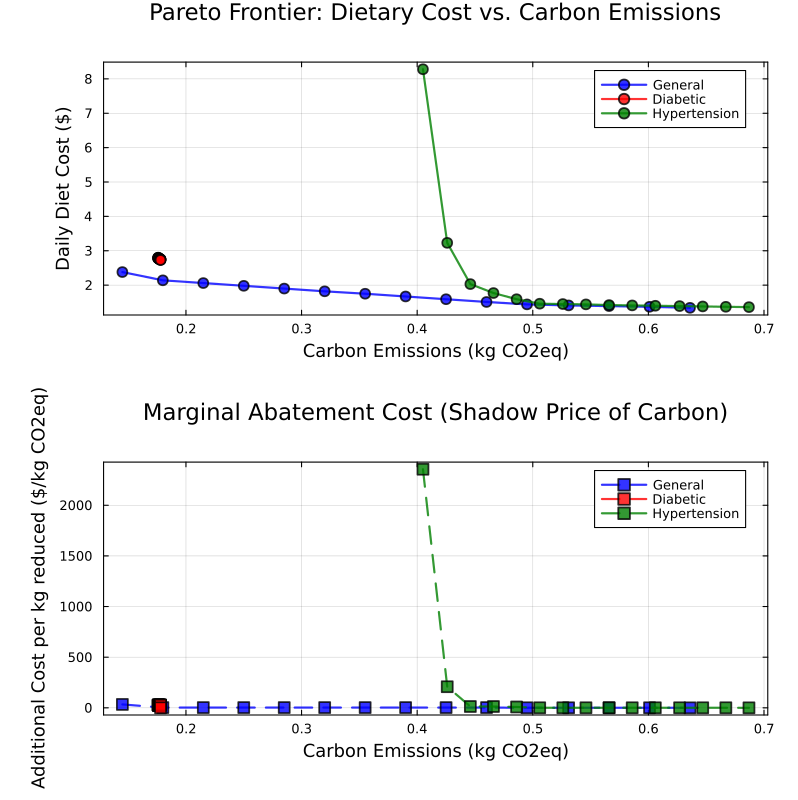

In [6]:
# ================== 5. Generate Dual-Perspective Visualization ==================
# Figure 1: Classic Pareto Frontier plot (cost vs carbon emissions)
plt1 = plot(title="Pareto Frontier: Dietary Cost vs. Carbon Emissions",
            xlabel="Carbon Emissions (kg CO2eq)",
            ylabel="Daily Diet Cost (\$)",
            legend=:topright,
            thickness_scaling=1.1,
            grid=true, framestyle=:box)

# Figure 2: Marginal abatement cost plot (Shadow Price vs carbon emission cap)
plt2 = plot(title="Marginal Abatement Cost (Shadow Price of Carbon)",
            xlabel="Carbon Emissions (kg CO2eq)",
            ylabel="Additional Cost per kg reduced (\$/kg CO2eq)",
            legend=:topright,
            thickness_scaling=1.1,
            grid=true, framestyle=:box)

colors = Dict("General"=>:blue, "Diabetic"=>:red, "Hypertension"=>:green)

for s in scenarios
    sub_df = filter(row -> row.Scenario == s, results_df)

    plot!(plt1, sub_df.Actual_Carbon, sub_df.Cost,
          label=s, color=colors[s], marker=:circle, markersize=5, linewidth=2, alpha=0.8)

    plot!(plt2, sub_df.Actual_Carbon, sub_df.Shadow_Price,
          label=s, color=colors[s], marker=:square, markersize=5, linewidth=2, linestyle=:dash, alpha=0.8)
end

# Stack both plots vertically
final_plot = plot(plt1, plt2, layout=(2, 1), size=(800, 800), margin=5Plots.mm)
display(final_plot)


## 4. Discussion of Results ##

### 4.1 Interpretation of the Pareto Frontier ###

The Pareto frontier quantifies the trade-off between affordability and environmental impact. In the computed frontiers, tighter carbon caps (left side) require higher-cost diets because the model must substitute toward lower-emission foods while still meeting nutrition constraints.

- Scenario differences: The Hypertension case typically lies above the General and Diabetic cases under tight carbon caps, reflecting the extra sodium and saturated fat limits that shrink the feasible set.
- Nonlinear trade-off: Cost increases are modest at first, then rise faster as the carbon cap approaches its minimum feasible level.

### 4.2 Analysis of Shadow Prices (Marginal Abatement Cost) ###

The shadow price of the carbon cap reflects the marginal cost of reducing one additional kilogram of $CO_2$eq while keeping the diet feasible.

- Binding vs. non-binding: When the cap is loose, the shadow price is near zero, indicating the environmental constraint is not active.
- Rising marginal cost: As the cap tightens, shadow prices increase, indicating diminishing returns in emissions reduction.

## 5. Conclusion ##

### 5.1. Summary of Findings ###

In this project, we applied multi-objective linear programming and the $\epsilon$-constraint method to quantify the cost-carbon trade-off in daily diets across three scenarios: General, Diabetic, and Hypertension. Our results show:

- A clear trade-off: tighter carbon caps lead to higher minimum-cost diets once the environmental constraint becomes binding.
- Medical constraints shift the frontier: additional sodium and saturated fat limits narrow the feasible set and raise costs under low-emission targets.
- Diminishing returns: shadow prices grow as the carbon cap approaches its minimum feasible level, indicating that the last units of emission reduction are the most expensive.

### 5.2. Future Direction: Incorporating Palatability via Variety Constraints ###

A limitation of the current model is that the optimal diet can be repetitive. To make recommendations more realistic, we could incorporate palatability and variety:

- Introduce upper-bound capacity constraints: limit each food item $i$ to a maximum of $x_i \le U_i$ to force a diverse basket.
- Add a palatability objective: use survey data to assign a satisfaction score $s_i$ and then maximize total satisfaction alongside the cost and carbon goals.
- Implementation: fix the carbon cap ($\epsilon$) and a minimum satisfaction level ($\delta$), then minimize cost. With only linear bounds, the model remains a linear program; adding discrete variety rules would make it a MILP.